In [2]:
# I import the different libreries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [3]:
# To start with the homework 2 i first upload the new dataset 

df_second_raw = pd.read_csv("data/Symbol_Info_extended.csv")

# And to do a fast check i just print the firsts observation

print("dataset firts observation", df_second_raw.shape)

df_second_raw.head()

dataset firts observation (3070, 21)


,symbol,company_name,sector,industry,country,market_cap,net_income,total_revenue,return_on_assets,return_on_equity,...,pe_trailing,pe_forward,earnings_growth,price_to_sales,price_to_book,revenue_growth,debt_to_equity,dividend_yield,payout_ratio,free_cashflow
0,A,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,United States,3.248796e+10,1.290000e+09,7.065000e+09,0.08533,0.19946,...,25.377481,17.515205,-0.036,4.598437,4.704534,0.070,51.390,0.89,0.2205,8.558750e+08
1,AA,Alcoa Corporation,Basic Materials,Aluminum,United States,1.883646e+10,1.027000e+09,1.265500e+10,0.04241,0.15427,...,18.302563,10.659156,-0.227,1.488460,2.759500,-0.052,37.019,0.56,0.1026,1.087375e+09
2,AAL,American Airlines Group Inc.,Industrials,Airlines,United States,9.160185e+09,2.020000e+08,5.599400e+10,0.01846,NaN,...,44.677420,6.256155,NaN,0.163592,-2.246918,0.108,NaN,NaN,0.0000,8.611250e+08
3,AAMI,Acadian Asset Management Inc.,Financial Services,Asset Management,United States,2.550323e+09,8.420000e+07,6.108000e+08,0.12664,1.11725,...,30.459576,12.513987,0.264,4.175381,32.910347,0.393,346.579,0.56,0.0553,1.208000e+08
4,AAOI,"Applied Optoelectronics, Inc.",Technology,Communication Equipment,United States,1.456326e+10,-4.333700e+07,5.070000e+08,-0.03317,-0.06126,...,NaN,38.032272,NaN,28.724379,12.958943,0.514,25.356,NaN,0.0000,-4.455833e+08


In [ ]:
# to select my company i separate and clean the dataset. In the following block it is possible to see first the data
# preparation and then the dataset that contain all the european companies. 

# It was better for me, first to do a clean up of the dataset and then choose the company. 

## STEP 0 and 1 - DATA PREPARATION and SELECTED COMPANY 

In [5]:

# I select all the columns that we need for this homework according to the file. 

columns= [

    "symbol", "company_name", "sector", "industry", "country", "market_cap",    # for the peer-selection var
    "return_on_assets", "return_on_equity", "profit_margins",  "pe_trailing",   # for the financial var
    "price_to_book", "revenue_growth", "debt_to_equity", "free_cashflow" 
]

df_second_raw= df_second_raw[columns].copy()

# Then of all i replace inifinite values  with NaN. 

df_second_raw = df_second_raw.replace([np.inf, -np.inf], np.nan)


# I set the columns based on the guide lines prof give us.

df_second_raw= df_second_raw[df_second_raw["market_cap"] > 0].copy()
df_second_raw["pe_trailing"] = df_second_raw["pe_trailing"].where(df_second_raw["pe_trailing"] > 0)        #first i convert to NaN and then and then I filter
df_second_raw["price_to_book"] = df_second_raw["price_to_book"].where(df_second_raw["price_to_book"] > 0)


# After saw the columns values, i decide to convert some values so they became more readeble

df_second_raw["market_cap_bill"] = df_second_raw["market_cap"] / 1e9
df_second_raw["free_cashflow_bill"] = df_second_raw["free_cashflow"] /1e9

df_second_raw["return_on_assets_perc"] = df_second_raw["return_on_assets"] *100
df_second_raw["return_on_equity_perc"] = df_second_raw["return_on_equity"] *100
df_second_raw["profit_margins_perc"] = df_second_raw["profit_margins"] *100
df_second_raw["revenue_growth_perc"] = df_second_raw["revenue_growth"] *100

df_second_raw= df_second_raw.round(2)

# And after all, this should be the final version of my dataset

print("Cleaned dataset:", df_second_raw.shape)
df_second_raw[["symbol", "company_name", "industry", "sector", "country", "market_cap_bill", "free_cashflow_bill","profit_margins_perc", "revenue_growth_perc" ]].head()

Cleaned dataset: (2970, 20)


,symbol,company_name,industry,sector,country,market_cap_bill,free_cashflow_bill,profit_margins_perc,revenue_growth_perc
0,A,"Agilent Technologies, Inc.",Diagnostics & Research,Healthcare,United States,32.49,0.86,18.26,7.0
1,AA,Alcoa Corporation,Aluminum,Basic Materials,United States,18.84,1.09,8.17,-5.2
2,AAL,American Airlines Group Inc.,Airlines,Industrials,United States,9.16,0.86,0.36,10.8
3,AAMI,Acadian Asset Management Inc.,Asset Management,Financial Services,United States,2.55,0.12,13.78,39.3
4,AAOI,"Applied Optoelectronics, Inc.",Communication Equipment,Technology,United States,14.56,-0.45,-8.55,51.4


In [6]:
# i proceded with the copy of the dataset from which i selected the group of my last digit of my id number (Europe)

df_s = df_second_raw.copy()

# to do the selection i create a list and then i append the countries that correspond to the european countries

europe_countries= ["Ireland", "Italy", "Germany", "Netherlands", "Luxembourg", "Spain", "France"]

df_s= df_s[df_s["country"].isin(europe_countries)].copy()

# and then i just print some of these to do a fast check

print("Country I selected", df_s["country"].unique())

df_s.tail()

Country I selected ['Ireland' 'Luxembourg' 'Netherlands' 'Germany' 'France' 'Spain' 'Italy']


,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow,market_cap_bill,free_cashflow_bill,return_on_assets_perc,return_on_equity_perc,profit_margins_perc,revenue_growth_perc
2595,STM,STMicroelectronics N.V.,Technology,Semiconductors,Netherlands,5.942478e+10,0.02,0.01,0.01,417.88,3.34,0.23,15.32,-3.605000e+08,59.42,-0.36,1.52,0.91,1.19,23.0
2621,SW,Smurfit Westrock Plc,Consumer Cyclical,Packaging & Containers,Ireland,1.995586e+10,0.03,0.02,0.01,52.85,1.08,0.01,78.83,1.360250e+09,19.96,1.36,3.01,2.11,1.22,0.7
2667,TEL,TE Connectivity plc,Technology,Electronic Components,Ireland,5.919063e+10,0.10,0.23,0.16,20.71,4.59,0.14,43.80,2.322250e+09,59.19,2.32,9.55,22.72,15.54,14.5
2694,TIGO,Millicom International Cellular S.A.,Communication Services,Telecom Services,Luxembourg,1.438176e+10,0.06,0.37,0.19,11.65,3.94,0.45,375.07,1.800625e+09,14.38,1.80,5.76,37.44,19.14,45.1
2763,TT,Trane Technologies plc,Industrials,Building Products & Equipment,Ireland,9.970043e+10,0.11,0.37,0.13,34.48,11.64,0.06,53.60,2.662363e+09,99.70,2.66,11.34,36.63,13.42,6.0


## STEP 2 - BUILD PEER GROUPS

In [8]:
# The company I select is "STMicroelectronics N.V.". Is a company in the sector of technology that provides 
# semiconductors based in Netherlands.
# The choiche of this company is principally the curiosity of studying such a company that is present in the Catania
# landascape too. 
# It has a market capitalization of 59 billions and a solid revenue growth of +23%, with a low dept financial structure (15,32%). Is has a weak
# profitability with margins and returns close to zero together with a negative free cash flows. 

my_company = "STMicroelectronics N.V."
my_industry = df_s[df_s["company_name"] == my_company]["industry"].values[0]

print("STMicroelectronics N.V.:", my_industry)


STMicroelectronics N.V.: Semiconductors


In [9]:
# --------------- GROUP A 

# I proceded to the first task i take all the companies and i filtered them by the industries in an descenging way
# based on the market capitalization in billions

task_A= df_second_raw[df_second_raw["industry"] == my_industry].sort_values("market_cap_bill",ascending= False)

# to verify that my company is in the list of all those who operate in the industry of semicondusctor: 

if len(task_A) > 10:

    # if it's in the top 10 the it sholud apper in the list of the the firsts ten companies
    top_10= task_A.head(10) 

    #if it's not in the top 10, then trhough the row STM, if STM is not in the top 10, it is added to the group regardless of its position
    if my_company not in top_10["company_name"].values: 
        STM_row= task_A[task_A["company_name"] == my_company]
        task_A= pd.concat([top_10, STM_row])
    else:
        task_A= top_10

print("Task A shape:", task_A.shape)

task_A[["symbol", "company_name", "industry", "sector", "country", "market_cap_bill", "free_cashflow_bill","profit_margins_perc", "revenue_growth_perc" ]]

# So, since STMicrolectrionics is not in the top 10 of the indistries that operate in the same indsitries, the STM_row
# has been added. it's observable in the columns of market_cap_bill, with an amount of 59.42 billions. 

Task A shape: (11, 20)


,symbol,company_name,industry,sector,country,market_cap_bill,free_cashflow_bill,profit_margins_perc,revenue_growth_perc
1967,NVDA,NVIDIA Corporation,Semiconductors,Technology,United States,5215.51,73.74,62.97,85.2
2759,TSM,Taiwan Semiconductor Manufacturing Company Lim...,Semiconductors,Technology,Taiwan,2098.03,719.16,46.50,35.1
277,AVGO,Broadcom Inc.,Semiconductors,Technology,United States,1960.82,25.50,36.57,29.5
1850,MU,"Micron Technology, Inc.",Semiconductors,Technology,United States,846.93,2.89,41.49,196.3
146,AMD,"Advanced Micro Devices, Inc.",Semiconductors,Technology,United States,762.32,7.17,13.37,37.8
1430,INTC,Intel Corporation,Semiconductors,Technology,United States,602.32,-8.30,-5.90,7.2
218,ARM,Arm Holdings plc,Semiconductors,Technology,United Kingdom,326.13,0.77,18.37,20.1
2783,TXN,Texas Instruments Incorporated,Semiconductors,Technology,United States,281.41,1.07,29.11,18.6
2249,QCOM,QUALCOMM Incorporated,Semiconductors,Technology,United States,251.02,9.59,22.31,-3.5
48,ADI,"Analog Devices, Inc.",Semiconductors,Technology,United States,193.41,3.87,26.01,37.2


In [21]:
# --------------- GROUP B 
# To do this task i use the reduced dataset that contain just the eruopean companis.

task_B= df_s[df_s["industry"] == my_industry].sort_values("market_cap_bill",ascending= False)

# to verify that my company is in the list of all those who operate in that industry i proceed as the same way for 
# the check i do above: 

if len(task_B) > 10:

    # if it's in the top 10 
    top_10= task_B.head(10)

    #if it's not in the top 10
    if my_company not in top_10["company_name"].values: 
        STM_row= task_B[task_B["company_name"] == my_company]
        task_B= pd.concat([top_10, STM_row])
    else: 
        task_B= top_10

print("Task B shape:", task_B.shape)

task_B[["symbol", "company_name", "industry", "sector", "country", "market_cap_bill", "free_cashflow_bill","profit_margins_perc", "revenue_growth_perc" ]]


Task B shape: (2, 20)


,symbol,company_name,industry,sector,country,market_cap_bill,free_cashflow_bill,profit_margins_perc,revenue_growth_perc
1986,NXPI,NXP Semiconductors N.V.,Semiconductors,Technology,Netherlands,79.90,3.12,21.03,12.2
2595,STM,STMicroelectronics N.V.,Semiconductors,Technology,Netherlands,59.42,-0.36,1.19,23.0


In [22]:
# CLOSEST MARKET CAPITALIZATION


semicond_market_cap= df_second_raw[df_second_raw["company_name"] == my_company]["market_cap_bill"].values[0]

# then i have to calculate the absolute distance. I calculate the absolute difference between the market cap 
# of each company in the dataset and the market cap of STMicroelectronics, to find the 10 most similar companies in terms of size

df_second_raw["distance"] = (df_second_raw["market_cap_bill"] - semicond_market_cap).abs()

# then i procede to verify if my company is not in the first ten companies that have a distance values that is in the 
# same market, on the base of the market capitalization. 

task_C = df_second_raw[df_second_raw["company_name"] != my_company].sort_values("distance").head(10)


STM_row = df_second_raw[df_second_raw["company_name"] == my_company]
task_C = pd.concat([STM_row, task_C])

print("Task C shape:", task_C.shape)
task_C[["symbol", "company_name", "industry", "country", "market_cap_bill", "distance"]]


Task C shape: (11, 21)


,symbol,company_name,industry,country,market_cap_bill,distance
2595,STM,STMicroelectronics N.V.,Semiconductors,Netherlands,59.42,0.00
2737,TRGP,Targa Resources Corp.,Oil & Gas Midstream,United States,59.40,0.02
1005,F,Ford Motor Company,Auto Manufacturers,United States,59.49,0.07
774,D,"Dominion Energy, Inc.",Utilities - Regulated Electric,United States,59.52,0.10
2015,OKE,"ONEOK, Inc.",Oil & Gas Midstream,United States,59.24,0.18
2667,TEL,TE Connectivity plc,Electronic Components,Ireland,59.19,0.23
1523,KEYS,"Keysight Technologies, Inc.",Scientific & Technical Instruments,United States,59.17,0.25
2536,SNOW,Snowflake Inc.,Software - Application,United States,59.69,0.27
1250,GWW,"W.W. Grainger, Inc.",Industrial Distribution,United States,58.91,0.51
74,AFL,Aflac Incorporated,Insurance - Life,United States,59.99,0.57


## STEP 3 - IS THE COMPANY PROFITABLE?

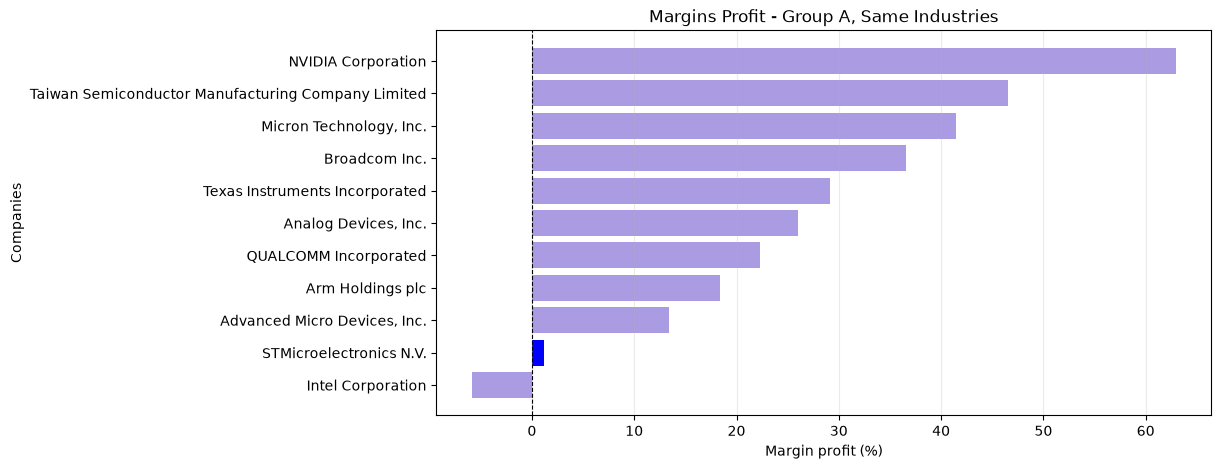

In [23]:
# ------------------------------------------- TASK A1 ------------------------------------------------------------

# to do this step I need to clean missing and invalid values.

task_A1= task_A.dropna(subset= ["profit_margins_perc"]).copy() 

# then i ordered the value in an ascending way, so it's more readeble

task_A1= task_A1.sort_values("profit_margins_perc", ascending= True)

# i set the labels

task_A1["label"] = task_A1["company_name"].fillna(task_A1["symbol"])

# then i have to set the color 

colors = ["blue" if name == my_company else "#ab9be2" for name in task_A1["company_name"]]

# i do the graph

fig, ax = plt.subplots(figsize= (10,5))

ax.barh(task_A1["label"], task_A1["profit_margins_perc"], color=colors)

ax.axvline (x=0, color="black", linewidth=0.8, linestyle ="--")

ax.set_title("Margins Profit - Group A, Same Industries")
ax.set_xlabel("Margin profit (%)")
ax.set_ylabel("Companies")
ax.grid(axis="x", alpha=0.25)

plt.show()


# STMicroelectronics ranks second to last in profit margins among its semiconductor peers, with only 1.19%. NVIDIA leads with around 63%, while 
# Intel is the only company with a negative margin. The majority of peers show margins well above 20%, confirming that STM is significantly 
# below the group median.

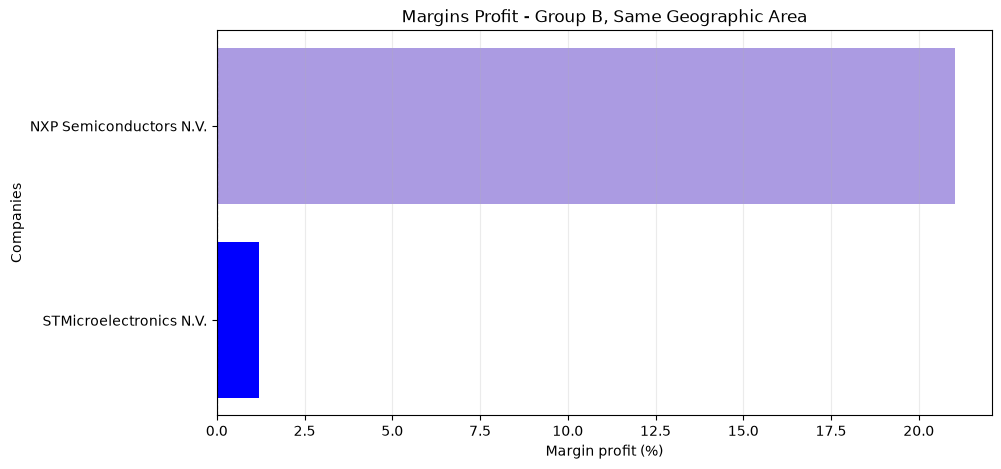

In [24]:
# ------------------------------------------- TASK B1 ------------------------------------------------------------

task_B1= task_B.dropna(subset= ["profit_margins_perc"]).copy() 

# then i ordered the value in an ascending way

task_B1= task_B1.sort_values("profit_margins_perc", ascending= True)

# i set the labels

task_B1["label"] = task_B1["company_name"].fillna(task_B1["symbol"])

# then i have to set the color 

colors = ["blue" if name == my_company else "#ab9be2" for name in task_B1["company_name"]]

# i do the graph

fig, ax = plt.subplots(figsize= (10,5))

ax.barh(task_B1["label"], task_B1["profit_margins_perc"], color=colors)

ax.axvline (x=0, color="black", linewidth=0.8, linestyle ="--")

ax.set_title("Margins Profit - Group B, Same Geographic Area")
ax.set_xlabel("Margin profit (%)")
ax.set_ylabel("Companies")
ax.grid(axis="x", alpha=0.25)

plt.show()

# The geographic group contains only two semiconductor companies from the Netherlands. NXP Semiconductors shows a margin of around 21%, while 
# STMicroelectronics has a margin of around 1,20%. STM is clearly below its only European peer.

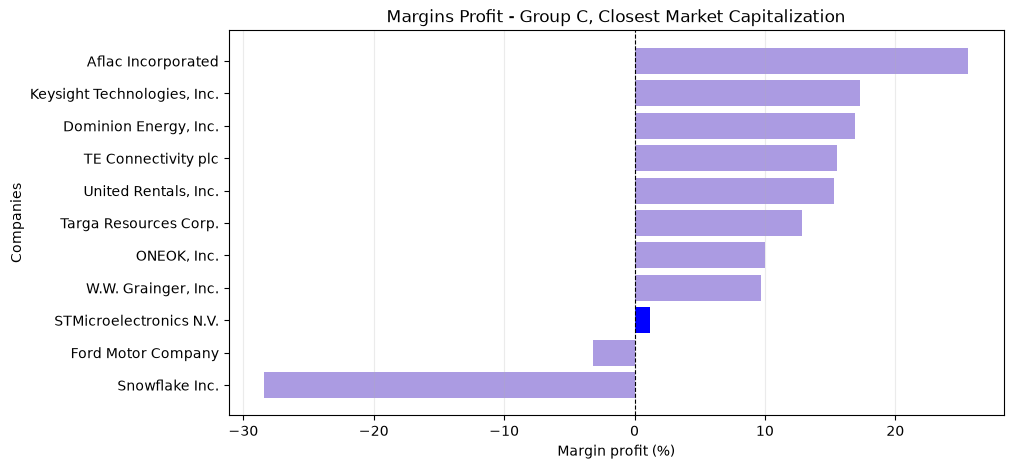

In [25]:
# ------------------------------------------- TASK C1 ------------------------------------------------------------

task_C1= task_C.dropna(subset= ["profit_margins_perc"]).copy() 

# then i ordered the value in an ascending way

task_C1= task_C1.sort_values("profit_margins_perc", ascending= True)

# i set the labels

task_C1["label"] = task_C1["company_name"].fillna(task_C1["symbol"])

# then i have to set the color 

colors = ["blue" if name == my_company else "#ab9be2" for name in task_C1["company_name"]]

# i do the graph

fig, ax = plt.subplots(figsize= (10,5))

ax.barh(task_C1["label"], task_C1["profit_margins_perc"], color=colors)

ax.axvline (x=0, color="black", linewidth=0.8, linestyle ="--")

ax.set_title("Margins Profit - Group C, Closest Market Capitalization")
ax.set_xlabel("Margin profit (%)")
ax.set_ylabel("Companies")
ax.grid(axis="x", alpha=0.25)

plt.show()


# Among companies of similar size, STM has one of the lowest positive margins, positioned just above zero. 
# Ford Motor Company and Snowflake show negative margins, while most peers are between 10% and 25%.We can observe that STM is below the 
# group median.

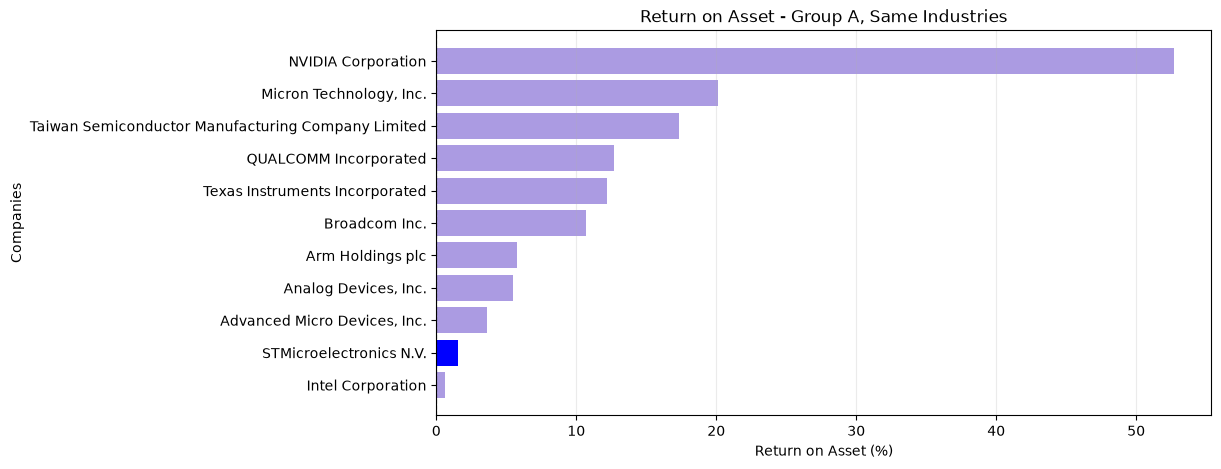

In [26]:

task_A1= task_A.dropna(subset= ["return_on_assets_perc"]).copy() 

# then i ordered the value in an ascending way, so it's more readeble

task_A1= task_A1.sort_values("return_on_assets_perc", ascending= True)

# i set the labels

task_A1["label"] = task_A1["company_name"].fillna(task_A1["symbol"])

# then i have to set the color 

colors = ["blue" if name == my_company else "#ab9be2" for name in task_A1["company_name"]]

# i do the graph

fig, ax = plt.subplots(figsize= (10,5))

ax.barh(task_A1["label"], task_A1["return_on_assets_perc"], color=colors)

ax.axvline (x=0, color="black", linewidth=0.8, linestyle ="--")

ax.set_title("Return on Asset - Group A, Same Industries")
ax.set_xlabel("Return on Asset (%)")
ax.set_ylabel("Companies")
ax.grid(axis="x", alpha=0.25)

plt.show()

# shows a ROA of around near zero (i think around 2%), placing it second to last, just above Intel. NVIDIA dominates with around 53%. The majority of semiconductor peers show 
# ROA above 5%, confirming STM is well below the industry median, indicating low efficiency in using its assets to generate profit.

## STEP 4 - IS THE COMPANY EXPENSIVE OR CHEAP?

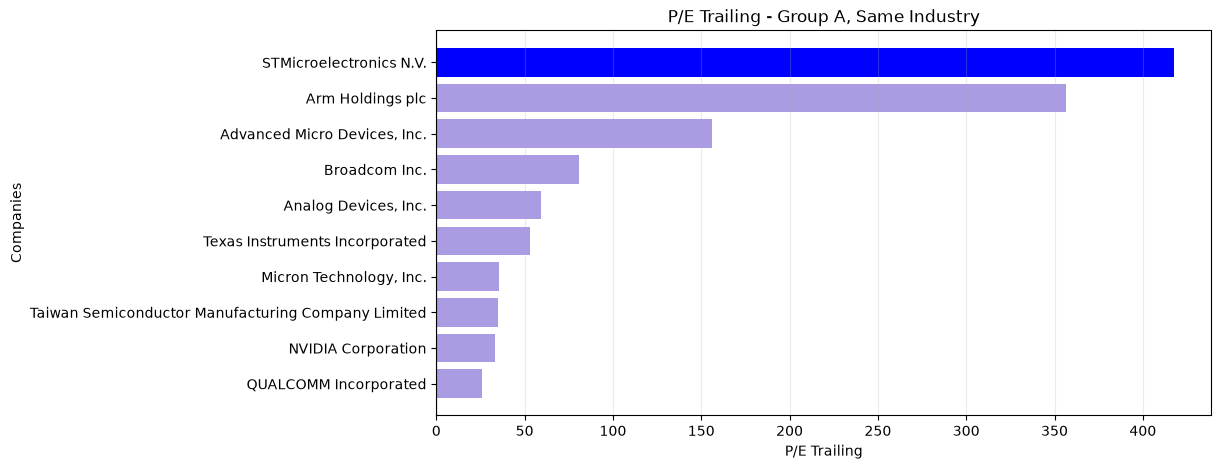

In [27]:
# I procede in the same way for this analysis. This code is more or less the same as the above. 
# I copy the task_A and then i create the object for the pe_trailing analysis.

task_A_pe = task_A.dropna(subset=["pe_trailing"]).copy()
task_A_pe = task_A_pe.sort_values("pe_trailing", ascending=True)
task_A_pe["label"] = task_A_pe["company_name"].fillna(task_A_pe["symbol"])

# I set the colors 

colors = ["blue" if name == my_company else "#ab9be2" for name in task_A_pe["company_name"]]

# I set the graph 

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(task_A_pe["label"], task_A_pe["pe_trailing"], color=colors)
ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("P/E Trailing - Group A, Same Industry")
ax.set_xlabel("P/E Trailing")
ax.set_ylabel("Companies")
ax.grid(axis="x", alpha=0.25)

plt.show()

# STMicroelectronics has the highest P/E trailing in the group at around 420 points, in the top in respect to all peers. This extremely high 
# value is not a signal of strong growth expectations, but rather a consequence of very low earnings. QUALCOMM has the lowest P/E at around 25 
# points. STM appears expensive on this metric, and it may be associated with its near-zero profit margins.


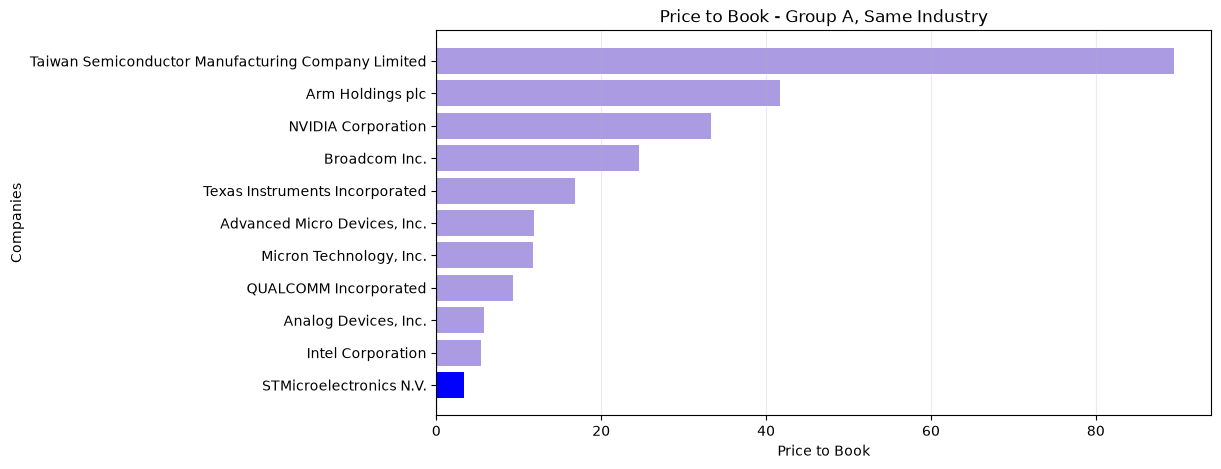

In [28]:
# I rpoceed on doing the same thing as above. So i copy the task_A and I sort the values based on the price to book

task_A_pe = task_A.dropna(subset=["price_to_book"]).copy()
task_A_pe = task_A_pe.sort_values("price_to_book", ascending=True)
task_A_pe["label"] = task_A_pe["company_name"].fillna(task_A_pe["symbol"])

# I set the colors 

colors = ["blue" if name == my_company else "#ab9be2" for name in task_A_pe["company_name"]]

# An then i set the graph
  
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(task_A_pe["label"], task_A_pe["price_to_book"], color=colors)
ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Price to Book - Group A, Same Industry")
ax.set_xlabel("Price to Book")
ax.set_ylabel("Companies")
ax.grid(axis="x", alpha=0.25)

plt.show()

# the lowest price to book ratio in the group at around 3 points. In the top we have Taiwan Semiconductor (around 90 points) and Arm Holdings 
# (around 41 point ) and NVIDIA (around 35). A low P/B suggests the market values STM close to its book value, which may reflect weak 
# profitability expectations. This is consistent with the low margins observed earlier.

## STEP 5 - IS THE COMPANY GROWING? 

In [29]:
# To do the 5th step i first analyze if there're some outliers

print(task_A["revenue_growth_perc"].describe())
print(task_B["revenue_growth_perc"].describe())
print(task_C["revenue_growth_perc"].describe())

# the output are equally distributed: the max max is 196, that is lower of the limit that prof set

count     11.000000
mean      44.227273
std       55.257725
min       -3.500000
25%       19.350000
50%       29.500000
75%       37.500000
max      196.300000
Name: revenue_growth_perc, dtype: float64
count     2.000000
mean     17.600000
std       7.636753
min      12.200000
25%      14.900000
50%      17.600000
75%      20.300000
max      23.000000
Name: revenue_growth_perc, dtype: float64
count    11.000000
mean     16.654545
std      12.575481
min     -10.200000
25%       8.650000
50%      19.600000
75%      25.500000
max      31.500000
Name: revenue_growth_perc, dtype: float64


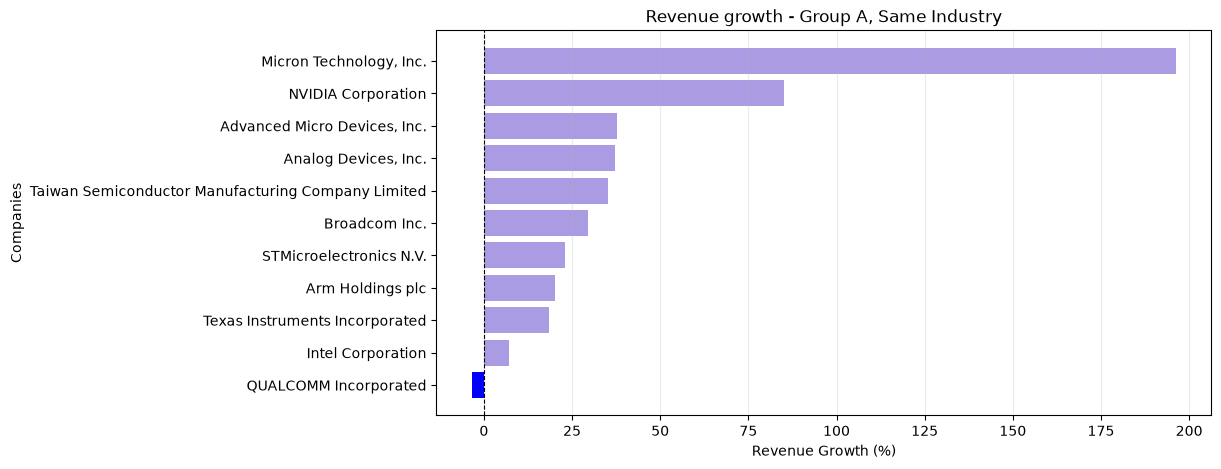

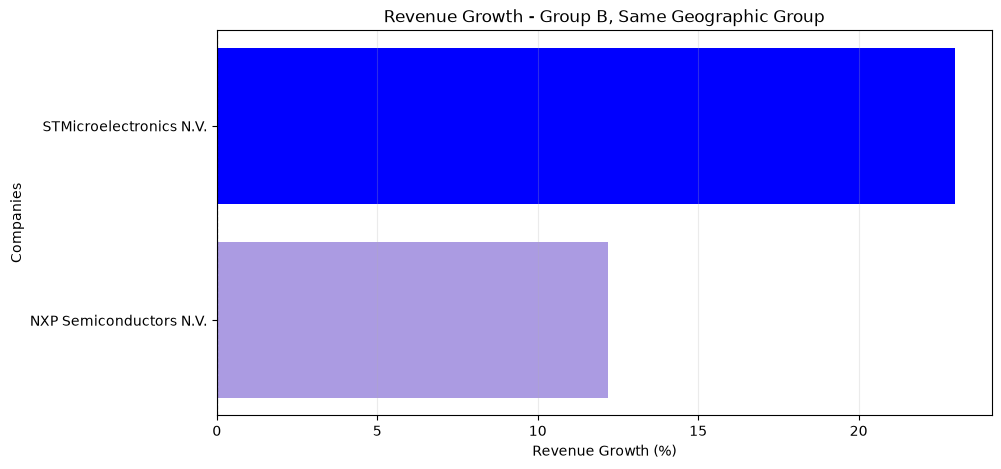

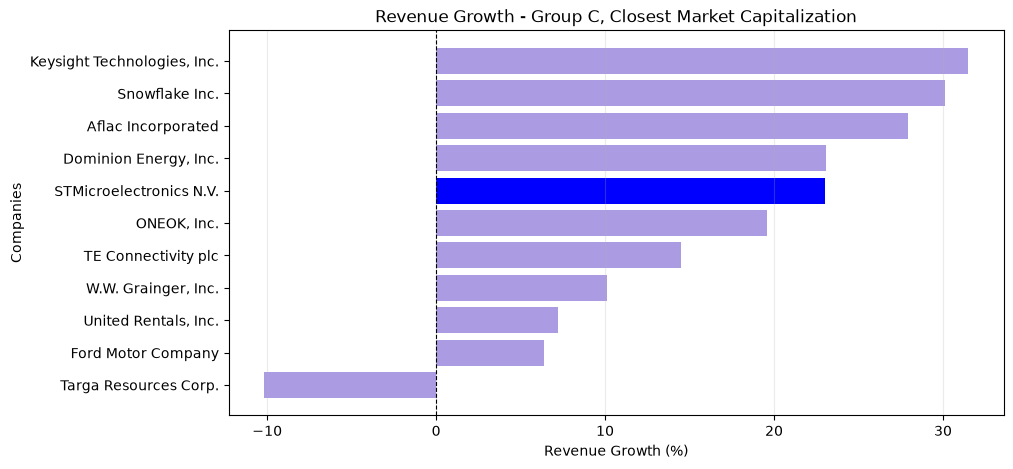

In [30]:
# ----------------------- ANALYSIS OF REVENUE GROWTH FOR GROUP A

task_A_rg= task_A.dropna(subset=["revenue_growth_perc"]).copy()
task_A_rg= task_A_rg.sort_values("revenue_growth_perc", ascending= True)
task_A_rg["label"] = task_A_rg["company_name"].fillna(task_A_rg["symbol"])

colors = ["blue" if name == my_company else "#ab9be2" for name in task_A_pe["company_name"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(task_A_rg["label"], task_A_rg["revenue_growth_perc"], color=colors)
ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Revenue growth - Group A, Same Industry")
ax.set_xlabel("Revenue Growth (%)")
ax.set_ylabel("Companies")
ax.grid(axis="x", alpha=0.25)

plt.show()

# ----------------------- ANALYSIS OF REVENUE GROWTH FOR GROUP B

task_B_rg = task_B.dropna(subset=["revenue_growth_perc"]).copy()
task_B_rg = task_B_rg.sort_values("revenue_growth_perc", ascending=True)
task_B_rg["label"] = task_B_rg["company_name"].fillna(task_B_rg["symbol"])

colors = ["blue" if name == my_company else "#ab9be2" for name in task_B_rg["company_name"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(task_B_rg["label"], task_B_rg["revenue_growth_perc"], color=colors)
ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Revenue Growth - Group B, Same Geographic Group")
ax.set_xlabel("Revenue Growth (%)")
ax.set_ylabel("Companies")
ax.grid(axis="x", alpha=0.25)

plt.show()


# ----------------------- ANALYSIS OF REVENUE GROWTH FOR GROUP C

task_C_rg = task_C.dropna(subset=["revenue_growth_perc"]).copy()
task_C_rg = task_C_rg.sort_values("revenue_growth_perc", ascending=True)
task_C_rg["label"] = task_C_rg["company_name"].fillna(task_C_rg["symbol"])

colors = ["blue" if name == my_company else "#ab9be2" for name in task_C_rg["company_name"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(task_C_rg["label"], task_C_rg["revenue_growth_perc"], color=colors)
ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Revenue Growth - Group C, Closest Market Capitalization")
ax.set_xlabel("Revenue Growth (%)")
ax.set_ylabel("Companies")
ax.grid(axis="x", alpha=0.25)

plt.show()

# STM shows a revenue growth of around 23%, placing it in the middle of the group. Micron Technology leads with around 195% and NVIDIA 
# follows with around 85%. QUALCOMM is the only company with negative growth at around -4%. STM's growth is positive and above several peers, 
# which is encouraging despite its low profitability.

#----------------------------

# Within the European peer group, STM outperforms its only comparable company. STM grows at around 23% while NXP Semiconductors grows at around 
# 11%. This confirms that STM is the stronger grower within its geographic group, even if profitability remains weak.

# -------------------------------

# Among size-comparable companies, STM ranks fifth with around 23% growth. Keysight Technologies leads at around 32%, while Targa Resources is 
# the only company with negative growth at around -11%. STM is above the group median, confirming a solid growth trajectory relative to companies 
# of similar size.


## STEP 6 - IS THE COMPANY FINANCIALLY SOLID?

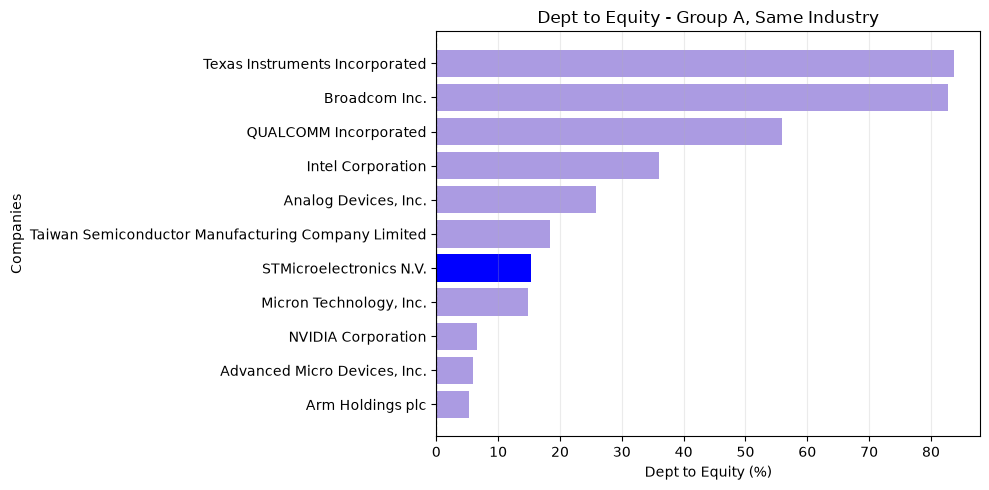

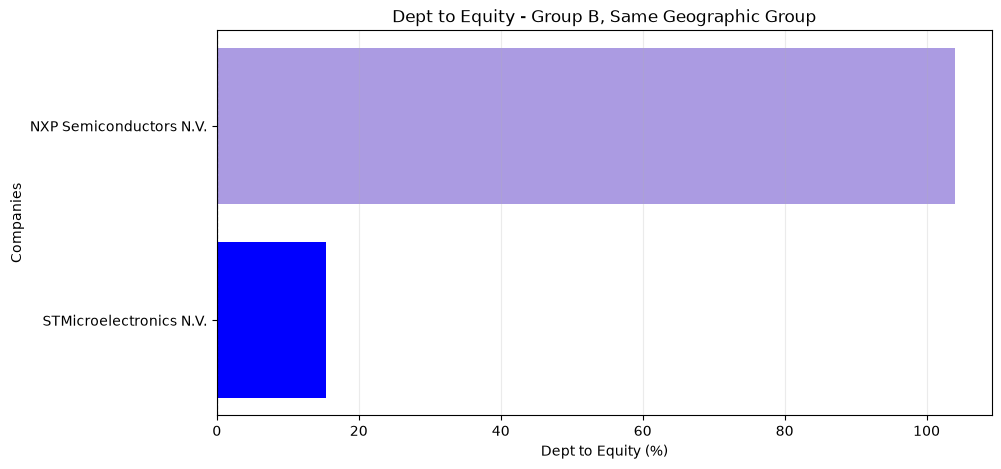

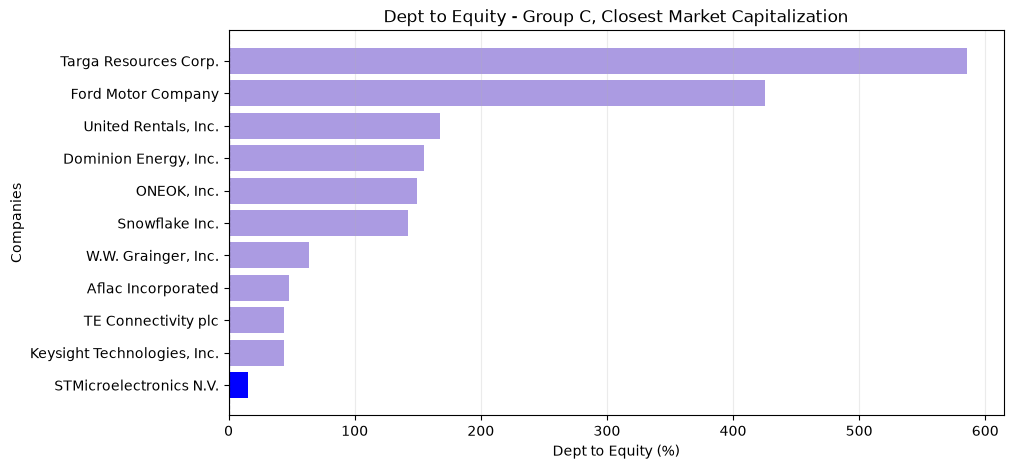

In [35]:
# --------------------------- DEPT TO EQUITY OF GROUP A

task_A_de= task_A.dropna(subset=["debt_to_equity"]).copy()
task_A_de= task_A_de.sort_values("debt_to_equity", ascending= True)
task_A_de["label"] = task_A_de["company_name"].fillna(task_A_de["symbol"])

colors = ["blue" if name == my_company else "#ab9be2" for name in task_A_de["company_name"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(task_A_de["label"], task_A_de["debt_to_equity"], color=colors)
ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Dept to Equity - Group A, Same Industry")
ax.set_xlabel("Dept to Equity (%)")
ax.set_ylabel("Companies")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

# --------------------------- DEPT TO EQUITY OF GROUP B

task_B_de = task_B.dropna(subset=["debt_to_equity"]).copy()
task_B_de = task_B_de.sort_values("debt_to_equity", ascending=True)
task_B_de["label"] = task_B_de["company_name"].fillna(task_B_de["symbol"])

colors = ["blue" if name == my_company else "#ab9be2" for name in task_B_de["company_name"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(task_B_de["label"], task_B_de["debt_to_equity"], color=colors)
ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Dept to Equity - Group B, Same Geographic Group")
ax.set_xlabel("Dept to Equity (%)")
ax.set_ylabel("Companies")
ax.grid(axis="x", alpha=0.25)

plt.show()


# --------------------------- DEPT TO EQUITY OF GROUP C

task_C_de = task_C.dropna(subset=["debt_to_equity"]).copy()
task_C_de = task_C_de.sort_values("debt_to_equity", ascending=True)
task_C_de["label"] = task_C_de["company_name"].fillna(task_C_de["symbol"])

colors = ["blue" if name == my_company else "#ab9be2" for name in task_C_de["company_name"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(task_C_de["label"], task_C_de["debt_to_equity"], color=colors)
ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Dept to Equity - Group C, Closest Market Capitalization")
ax.set_xlabel("Dept to Equity (%)")
ax.set_ylabel("Companies")
ax.grid(axis="x", alpha=0.25)

plt.show()